# Disorder Distribution in PDB vs Human Proteome

```
# Copyright 2025 Peptone Ltd
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
```

In [1]:
import gzip
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from tqdm import tqdm

from peptonebench.config import PEPTONEDB_PATH

data_dir = os.path.join(PEPTONEDB_PATH, "sequences")
os.makedirs(data_dir, exist_ok=True)

data_dir = "/raid/app/michele/IDPgen/peptonebench/datasets/sequences"

In [2]:
# set bigger font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIG_SIZE = 16

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIG_SIZE)  # fontsize of the figure title

In [3]:
pdb_seqres_file = os.path.join(data_dir, "pdb/pdb_seqres.txt.gz")
if not os.path.exists(pdb_seqres_file):
    print(f"Downloading {pdb_seqres_file}")
    url = "https://files.rcsb.org/pub/pdb/derived_data/pdb_seqres.txt.gz"
    response = requests.get(url)

    with open(pdb_seqres_file, "wb") as file:
        file.write(response.content)

counter = 0
with gzip.open(pdb_seqres_file, "rt") as fin, open(f"{data_dir}/pdb/pdb_seqres-protein.fasta", "w") as fout:
    for line in fin:
        if line.startswith(">") and "mol:protein" in line:
            fout.write(line)
            fout.write(next(fin))
            counter += 1
print(f"Found {counter:_} protein sequences")

Found 1_000_724 protein sequences


In [4]:
if not os.path.exists(f"{data_dir}/pdb/clustered_rep_seq.fasta"):
    import subprocess

    print("clustering with mmseqs2...")
    subprocess.run(
        [
            "mmseqs_avx2",
            "easy-cluster",
            f"{data_dir}/pdb/pdb_seqres-protein.fasta",
            f"{data_dir}/pdb/clustered",
            "/tmp",
        ],
        check=True,
    )
else:
    print("clustered_rep_seq.fasta already exists, skipping clustering step")

clustered_rep_seq.fasta already exists, skipping clustering step


In [5]:
adopt_filename = f"{data_dir}/pdb/adopt2_gscores-pdb.csv.gz"
if not os.path.exists(adopt_filename):
    raise ValueError(f"use ADOPT2 to create {adopt_filename}")
gscores_adopt2_df = pd.read_csv(
    adopt_filename,
    index_col="label",
    converters={"gscores_adopt2": lambda s: np.asarray(json.loads(s), dtype=float)},
).dropna(subset=["mean_gscore_adopt2"])
gscores_adopt2_df

,sequence,mean_gscore_adopt2,gscores_adopt2
label,,,
2qie_A mol:protein length:148 Molybdopterin-converting factor subunit 2,MKQFEIVIEPIQTEQYREFTINEYQGAVVVFTGHVREWTKGVKTEY...,0.084209,"[0.07392445206642151, 0.08265159279108047, 0.0..."
2qih_B mol:protein length:157 protein UspA1,MRGSHHHHHHGSATSANTDRIATAELGIAENKKDAQIAKAQANENK...,0.465907,"[0.7701073884963989, 0.7847035527229309, 0.845..."
2qik_A mol:protein length:285 UPF0131 protein ykqA,MNSLLFVYGTLRKHEKNHHLLAQSACINEQARTKGSLFAAKEGPTV...,0.072051,"[0.13024090230464935, 0.0833941251039505, 0.08..."
3c9f_B mol:protein length:557 5'-nucleotidase,MSLASFPHRNLTWNDINFVHTTDTHGWYSGHINQPLYHANWGDFIS...,0.116556,"[0.37157344818115234, 0.48727983236312866, 0.6..."
3c9n_C mol:protein length:9 Peptide antigen,VQQESSFVM,0.686804,"[0.6199784874916077, 0.7146599292755127, 0.736..."
...,...,...,...
6tdu_AM mol:protein length:267 oligomycin sensitivity conferring protein (OSCP),MHMRRAVSVFGRCRSLNGLRNYAVPSPKYIEIYQSDFSRNAYPLEL...,0.207614,"[0.32494014501571655, 0.4951254725456238, 0.59..."
6tdu_AN mol:protein length:103 inhibitor of F1 (IF1),MAAACAVRGFTTARPMLTPNKVKVPGRKPQDEEDLTWAEADRKLTP...,0.438792,"[0.5143599510192871, 0.7716733813285828, 0.765..."
6tdu_AO mol:protein length:104 ATP synthase subunit c,MQRGSSITKVVRRAALARSTRNAAIAYEVTVNGANLIGAGMAASGV...,0.202954,"[0.331498920917511, 0.6381198167800903, 0.7214..."


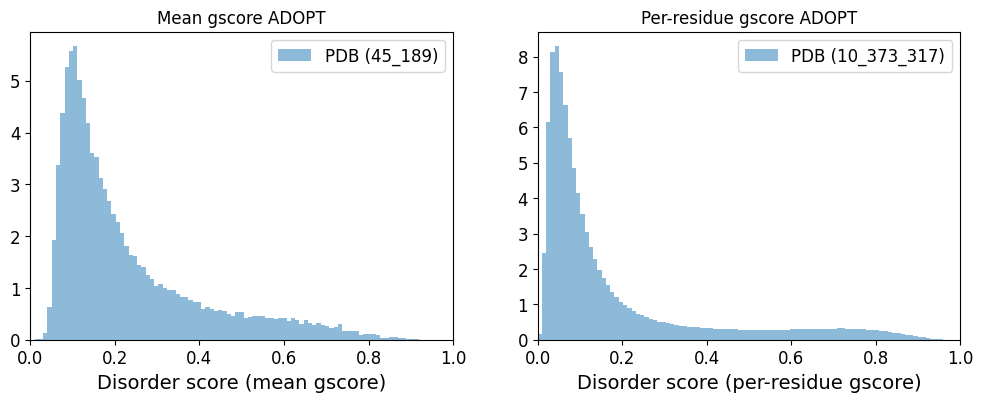

In [6]:
def plot_histograms(dfs: list[pd.DataFrame], labels: list[str] = None):
    if isinstance(dfs, pd.DataFrame):
        dfs = [dfs]
    if labels is None:
        labels = [""] * len(dfs)
    if isinstance(labels, str):
        labels = [labels]
    assert len(dfs) == len(labels), f"len(dfs) = {len(dfs)} != len(labels) = {len(labels)}"

    x_bins = np.linspace(0, 1, 100)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("Mean gscore ADOPT")
    for df, label in zip(dfs, labels):
        plt.hist(
            df["mean_gscore_adopt2"].to_numpy(),
            bins=x_bins,
            alpha=0.5,
            density=True,
            label=f"{label} ({len(df):_})",
        )
    plt.xlabel("Disorder score (mean gscore)")
    plt.xlim(0, 1)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title("Per-residue gscore ADOPT")
    for df, label in zip(dfs, labels):
        plt.hist(
            np.concatenate(list(df["gscores_adopt2"])),
            bins=x_bins,
            alpha=0.5,
            density=True,
            label=f"{label} ({df['gscores_adopt2'].apply(len).sum():_})",
        )
    plt.xlabel("Disorder score (per-residue gscore)")
    plt.xlim(0, 1)
    plt.legend()
    plt.show()


plot_histograms([gscores_adopt2_df], ["PDB"])

In [7]:
# Load SIFTS uniprot_segments_observed data
sifts_file = f"{data_dir}/pdb/uniprot_segments_observed.csv.gz"
if not os.path.exists(sifts_file):
    print(f"Downloading {sifts_file}...")
    url = "https://ftp.ebi.ac.uk/pub/databases/msd/sifts/flatfiles/csv/uniprot_segments_observed.csv.gz"
    response = requests.get(url)
    with open(sifts_file, "wb") as f:
        f.write(response.content)

sifts_df = pd.read_csv(sifts_file, skiprows=1)
sifts_df

/tmp/ipykernel_133330/1355797224.py:10: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  sifts_df = pd.read_csv(sifts_file, skiprows=1)


,PDB,CHAIN,SP_PRIMARY,RES_BEG,RES_END,PDB_BEG,PDB_END,SP_BEG,SP_END
0,101m,A,P02185,1,154,0,153,1,154
1,103m,A,P02185,1,154,0,153,1,154
2,102l,A,P00720,1,163,1,162,1,162
3,105m,A,P02185,1,153,1,153,2,154
4,106m,A,P02185,1,154,0,153,1,154
...,...,...,...,...,...,...,...,...,...
1411024,9y9z,v,S8GBZ2,842,953,842,953,842,953
1411025,9y9z,w,S8GBZ2,842,953,842,953,842,953
1411026,9y9z,x,S8GBZ2,842,953,842,953,842,953
1411027,9y9z,y,S8GBZ2,842,953,842,953,842,953


In [8]:
# Create filtered gscores (only observed residues) for all sequences

filename = f"{data_dir}/pdb/adopt2_gscores-pdb_observed.csv.gz"
if os.path.exists(filename):
    gscores_adopt2_observed_df = pd.read_csv(
        filename,
        index_col="label",
        converters={
            "gscores_adopt2": lambda s: np.asarray(json.loads(s), dtype=float),
            "observation_mask": lambda s: np.asarray(json.loads(s), dtype=bool),
        },
    )
else:
    from collections import defaultdict

    observed_segments = defaultdict(list)
    for _, row in tqdm(sifts_df.iterrows(), total=len(sifts_df), desc="Building segment lookup"):
        pdb = str(row["PDB"]).lower()
        chain = str(row["CHAIN"])
        res_beg = int(row["RES_BEG"])
        res_end = int(row["RES_END"])
        observed_segments[(pdb, chain)].append((res_beg, res_end))

    print(f"Built lookup for {len(observed_segments):_} PDB chains")

    def create_observation_mask(label: str, seq_length: int, observed_segments: dict) -> np.ndarray:
        pdb_id = label.split("_")[0].lower()
        chain_id = label.split("_")[1].split()[0]

        mask = np.zeros(seq_length, dtype=bool)
        segments = observed_segments.get((pdb_id, chain_id), [])

        for res_beg, res_end in segments:
            start_idx = res_beg - 1
            end_idx = res_end
            if start_idx >= 0 and end_idx <= seq_length:
                mask[start_idx:end_idx] = True

        return mask

    observation_masks = []
    n_found = 0
    n_missing = 0

    for label in tqdm(gscores_adopt2_df.index, desc="Creating observation masks"):
        mask = create_observation_mask(label, len(gscores_adopt2_df.loc[label, "sequence"]), observed_segments)
        observation_masks.append(mask)

        if mask.any():
            n_found += 1
        else:
            n_missing += 1

    gscores_adopt2_df["observation_mask"] = observation_masks

    print(
        f"Found SIFTS data for {n_found:_} / {len(gscores_adopt2_df):_} sequences ({100 * n_found / len(gscores_adopt2_df):.1f}%)",
    )
    print(f"Missing SIFTS data for {n_missing:_} sequences")

    gscores_adopt2_observed_df = gscores_adopt2_df[gscores_adopt2_df["observation_mask"].apply(lambda x: x.any())]
    print(f"saving to {filename}")
    tmp_df = gscores_adopt2_observed_df.copy()
    tmp_df["gscores_adopt2"] = tmp_df["gscores_adopt2"].apply(lambda x: json.dumps(x.tolist()))
    tmp_df["observation_mask"] = tmp_df["observation_mask"].apply(
        lambda x: "[" + ",".join(str(int(b)) for b in x) + "]",
    )
    tmp_df.to_csv(filename, compression="gzip")
    del tmp_df
gscores_adopt2_observed_df

,sequence,mean_gscore_adopt2,gscores_adopt2,observation_mask
label,,,,
2qie_A mol:protein length:148 Molybdopterin-converting factor subunit 2,MKQFEIVIEPIQTEQYREFTINEYQGAVVVFTGHVREWTKGVKTEY...,0.084209,"[0.07392445206642151, 0.08265159279108047, 0.0...","[True, True, True, True, True, True, True, Tru..."
2qih_B mol:protein length:157 protein UspA1,MRGSHHHHHHGSATSANTDRIATAELGIAENKKDAQIAKAQANENK...,0.465907,"[0.7701073884963989, 0.7847035527229309, 0.845...","[False, False, False, False, False, False, Fal..."
2qik_A mol:protein length:285 UPF0131 protein ykqA,MNSLLFVYGTLRKHEKNHHLLAQSACINEQARTKGSLFAAKEGPTV...,0.072051,"[0.13024090230464935, 0.0833941251039505, 0.08...","[True, True, True, True, True, True, True, Tru..."
3c9f_B mol:protein length:557 5'-nucleotidase,MSLASFPHRNLTWNDINFVHTTDTHGWYSGHINQPLYHANWGDFIS...,0.116556,"[0.37157344818115234, 0.48727983236312866, 0.6...","[False, False, False, False, True, True, True,..."
3c9q_A mol:protein length:205 Uncharacterized protein C8orf32,SEGNGPAAVHYQPASPPRDACVYSSCYCEENVWKLCEYIKNHDQYP...,0.115856,"[0.6177971363067627, 0.785060465335846, 0.8033...","[False, False, False, False, False, False, Fal..."
...,...,...,...,...
6iai_A mol:protein length:121 Protein of uncharacterized function (DUF1076),MGSSHHHHHHSSGLVPRGSHMFLTFPNVAITRDNRIDKLSENDLEL...,0.242540,"[0.5113784670829773, 0.6255226731300354, 0.655...","[False, False, False, False, False, False, Fal..."
6iam_C mol:protein length:4 Small ubiquitin-related modifier 5,EAKP,0.323356,"[0.21903656423091888, 0.30822575092315674, 0.3...","[True, True, True, True]"
6ian_B mol:protein length:328 Intraflagellar transport protein 74,GAASMGPGRQVGDRSYYIGLLRPKITELTTEIERLNEQEELIVKGG...,0.145653,"[0.7812391519546509, 0.8003931641578674, 0.826...","[False, False, False, False, False, False, Fal..."


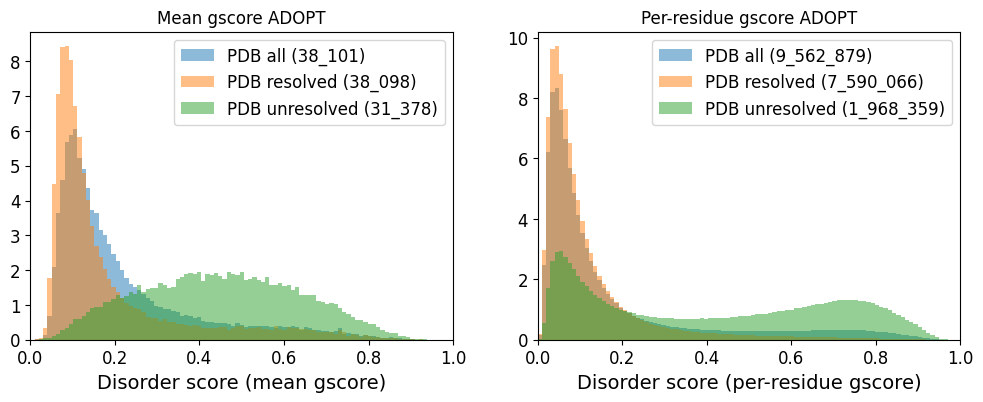

In [9]:
observed_gscores = gscores_adopt2_observed_df.apply(
    lambda row: row["gscores_adopt2"][row["observation_mask"]],
    axis=1,
).to_list()
labels = [label for label, gs in zip(gscores_adopt2_observed_df.index, observed_gscores) if sum(np.isfinite(gs)) > 0]
observed_gscores = [gs for gs in observed_gscores if sum(np.isfinite(gs)) > 0]
mean_observed_gscores = [np.nanmean(gs) for gs in observed_gscores]
pdb_resolved_df = pd.DataFrame(
    {"mean_gscore_adopt2": mean_observed_gscores, "gscores_adopt2": observed_gscores},
    index=labels,
)

unresolved_gscores = gscores_adopt2_observed_df.apply(
    lambda row: row["gscores_adopt2"][~row["observation_mask"]],
    axis=1,
).to_list()
unresolved_gscores = [gs for gs in unresolved_gscores if sum(np.isfinite(gs)) > 0]
mean_unresolved_gscores = [np.nanmean(gs) for gs in unresolved_gscores]


plot_histograms(
    [
        gscores_adopt2_observed_df,
        pdb_resolved_df,
        pd.DataFrame({"mean_gscore_adopt2": mean_unresolved_gscores, "gscores_adopt2": unresolved_gscores}),
    ],
    ["PDB all", "PDB resolved", "PDB unresolved"],
)

In [10]:
# Human Proteome
if not os.path.exists(f"{data_dir}/human_proteome/clustered_rep_seq.fasta"):
    import subprocess

    url = "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000005640%29+AND+%28model_organism%3A9606%29"
    response = requests.get(url)
    with open(f"{data_dir}/human_proteome/human_proteome.fasta", "w") as f:
        f.write(response.text)

    print("clustering with mmseqs2...")
    subprocess.run(
        [
            "mmseqs_avx2",
            "easy-cluster",
            f"{data_dir}/human_proteome/human_proteome.fasta",
            f"{data_dir}/human_proteome/clustered",
            "/tmp",
        ],
        check=True,
    )
else:
    print("clustered_rep_seq.fasta already exists, skipping clustering step")

clustered_rep_seq.fasta already exists, skipping clustering step


In [11]:
adopt_filename = f"{data_dir}/human_proteome/adopt2-human_proteome.csv.gz"
if not os.path.exists(adopt_filename):
    raise ValueError(f"use ADOPT2 to create {adopt_filename}")
human_proteome_df = pd.read_csv(
    adopt_filename,
    index_col="label",
    converters={"gscores_adopt2": lambda s: np.asarray(json.loads(s), dtype=float)},
).dropna(subset=["mean_gscore_adopt2"])
human_proteome_df

,sequence,mean_gscore_adopt2,gscores_adopt2
label,,,
tr|F5GX99|F5GX99_HUMAN ClpB family mitochondrial disaggregase OS=Homo sapiens OX=9606 GN=CLPB PE=1 SV=2,MLGSLVLRRKALAPRLLLRLLRSPTLRGHGGASGRNVTTGSLGEPQ...,0.732824,"[0.5626553893089294, 0.6838881373405457, 0.778..."
tr|F5GXA4|F5GXA4_HUMAN Stereocilin OS=Homo sapiens OX=9606 GN=STRC PE=4 SV=1,MELLACFSPVLWDLLQREKSVWALQILVQAYLHMPPENLQQLVLSA...,0.096414,"[0.08610641956329346, 0.11453385651111603, 0.0..."
tr|F5GXB6|F5GXB6_HUMAN WD repeat and SOCS box containing 2 (Fragment) OS=Homo sapiens OX=9606 GN=WSB2 PE=1 SV=1,MLSPAPEEPLLLAELKPGRPHQFDWKSSCETWSVAFSPDGSWFAWS...,0.156961,"[0.46762391924858093, 0.4582716226577759, 0.56..."
tr|F5GXB9|F5GXB9_HUMAN Anaphase promoting complex subunit 15 (Fragment) OS=Homo sapiens OX=9606 GN=ANAPC15 PE=1 SV=8,MSTLFPSLFPRVTETLWFNLDRPCVEETELQQQEQQHQAWLQSI,0.466741,"[0.43936896324157715, 0.5528845191001892, 0.55..."
tr|F5GXC1|F5GXC1_HUMAN phosphoinositide phospholipase C (Fragment) OS=Homo sapiens OX=9606 GN=PLCD3 PE=1 SV=1,MLRGSRLRKIRSRTWHKERLYRLQEDGLSVWFQRRIPRAPSQHIFF...,0.159428,"[0.059804365038871765, 0.11896879971027374, 0...."
...,...,...,...
tr|F8WBV2|F8WBV2_HUMAN Solute carrier family 51 member A OS=Homo sapiens OX=9606 GN=SLC51A PE=1 SV=1,MEPGRTQIKLDPRYTADLLEVLKTNYGIPSACFSQPPTAAQLLRDR...,0.203076,"[0.262962281703949, 0.37287434935569763, 0.527..."
tr|F8WBV3|F8WBV3_HUMAN Zinc finger protein 28 OS=Homo sapiens OX=9606 GN=ZNF28 PE=4 SV=2,MLENYRNLVSLDFRSVTQAKVQWCHLGSLQPPLPRFKQFSCLSLPS...,0.631746,"[0.5184338688850403, 0.5930783152580261, 0.608..."
tr|F8WBV4|F8WBV4_HUMAN Paraoxonase 3 OS=Homo sapiens OX=9606 GN=PON3 PE=1 SV=1,MGKLVALVLLGVGLSLVGEMFLAFRERVNASREVEPVEPENCHLIE...,0.284388,"[0.16356156766414642, 0.2087223082780838, 0.16..."


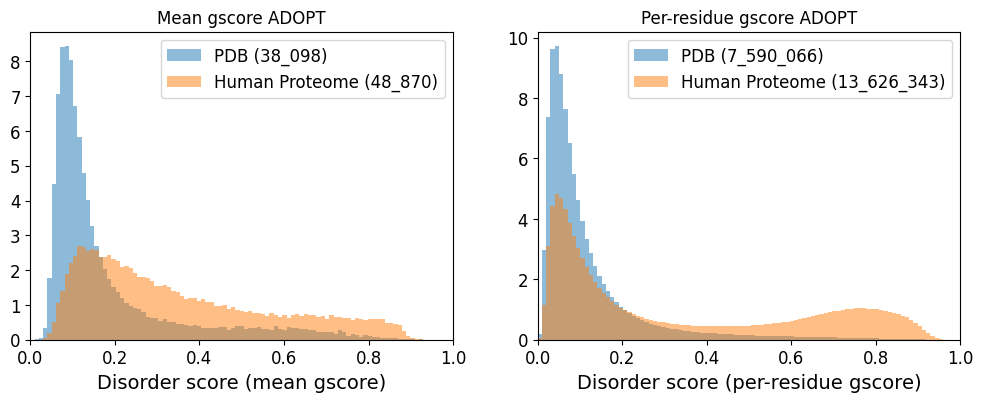

In [12]:
plot_histograms([pdb_resolved_df, human_proteome_df], ["PDB", "Human Proteome"])

Saved to figure_proteome.png


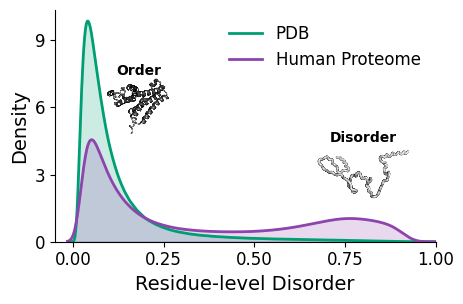

In [13]:
from KDEpy import FFTKDE

save_path = "figure_proteome.png"
# save_path = ""
s = 0.8

results = []
# for gs in [pdb_resolved_df["mean_gscore_adopt2"].to_numpy(), human_proteome_df["mean_gscore_adopt2"].to_numpy()]:
for gs in [
    np.concatenate(pdb_resolved_df["gscores_adopt2"].to_list()),
    np.concatenate(human_proteome_df["gscores_adopt2"].to_list()),
]:
    data = gs[~np.isnan(gs)]
    x = np.linspace(-0.015, 1, 500)
    density = FFTKDE(bw="silverman").fit(data).evaluate(x)
    results.append((data, x, density))

fig, ax = plt.subplots(figsize=(6 * s, 4 * s))

colors = ["#009E73", "#8E44AD"]  # green, purple
linestyles = ["-", "-"]
alphas = [0.2, 0.2]

for i, ((data, x, density), label) in enumerate(zip(results, ["PDB", "Human Proteome"])):
    n_samples = len(data)
    ax.plot(
        x,
        density,
        color=colors[i],
        linestyle=linestyles[i],
        linewidth=2,
        label=f"{label}",  # (n={n_samples:,})",
    )
    ax.fill_between(x, density, alpha=alphas[i], color=colors[i])

ax.set_xlabel("Residue-level Disorder")
ax.set_ylabel("Density")
ax.set_xlim(-0.05, 1)
ax.set_ylim(0, None)
ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0, 3, 6, 9])
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

import matplotlib.image as mpimg
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

zoom = 0.25
text_dict = {
    "ha": "center",
    "va": "bottom",
    "fontsize": 10,
    "fontweight": "bold",
}

x_order = 0.18
y_order = 6
ax.text(x_order, y_order + 1.3, "Order", **text_dict)
img_folded = mpimg.imread("Order.png")
imagebox_folded = OffsetImage(img_folded, zoom=zoom)
ab_folded = AnnotationBbox(
    imagebox_folded,
    (x_order, y_order),
    frameon=False,
    xycoords="data",
    box_alignment=(0.5, 0.5),
)
ax.add_artist(ab_folded)

x_disorder = 0.8
y_disorder = 3.0
ax.text(x_disorder, y_disorder + 1.3, "Disorder", **text_dict)
img_disordered = mpimg.imread("Disorder.png")
imagebox_disordered = OffsetImage(img_disordered, zoom=zoom)
ab_disordered = AnnotationBbox(
    imagebox_disordered,
    (x_disorder, y_disorder),
    frameon=False,
    xycoords="data",
    box_alignment=(0.5, 0.5),
)
ax.add_artist(ab_disordered)

plt.tight_layout()

if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved to {save_path}")

plt.show()